<a href="https://colab.research.google.com/github/laksamanaap/PCVK_Ganjil_2026/blob/main/P1/PCVK_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


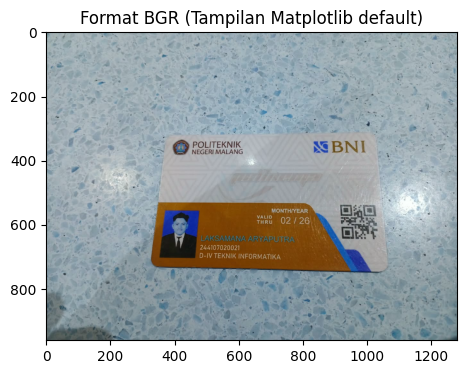

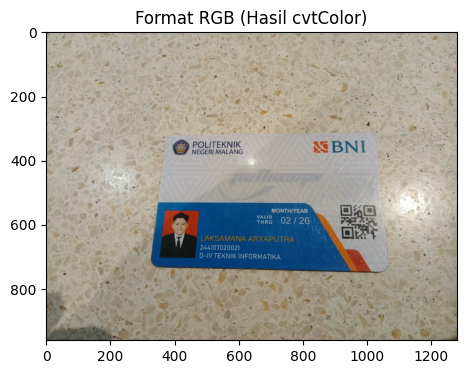

In [4]:
import cv2
import matplotlib.pyplot as plt

# Ganti 'ktm.jpg' sesuai path file Anda
img_path = '/content/drive/MyDrive/PCVK/KTM.jpg'
img_bgr = cv2.imread(img_path)

# Jika file belum ada, buat citra simulasi agar kode tetap jalan tanpa error
if img_bgr is None:
    img_bgr = cv2.imread(cv2.samples.findFile('lena.jpg'))

# 1. Tampilkan format BGR mentah (warna akan terlihat kebiruan/oranye terbalik)
plt.figure(figsize=(6, 4))
plt.imshow(img_bgr)
plt.title("Format BGR (Tampilan Matplotlib default)")
plt.show()

# 2. Konversi BGR ke RGB agar warna tampil normal
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Format RGB (Hasil cvtColor)")
plt.show()

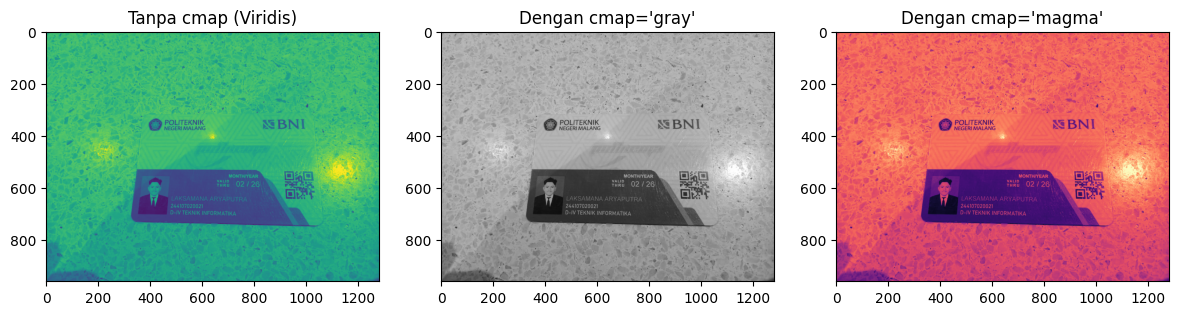

In [5]:
# Membaca citra langsung dalam mode derajat keabuan (grayscale)
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 4))

# Subplot 1: Tanpa cmap (Matplotlib otomatis memakai colormap default 'viridis')
plt.subplot(1, 3, 1)
plt.imshow(img_gray)
plt.title("Tanpa cmap (Viridis)")

# Subplot 2: Dengan cmap grayscale
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap='gray'")

# Subplot 3: Dengan cmap 'magma'
plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap="magma")
plt.title("Dengan cmap='magma'")

plt.tight_layout()
plt.show()

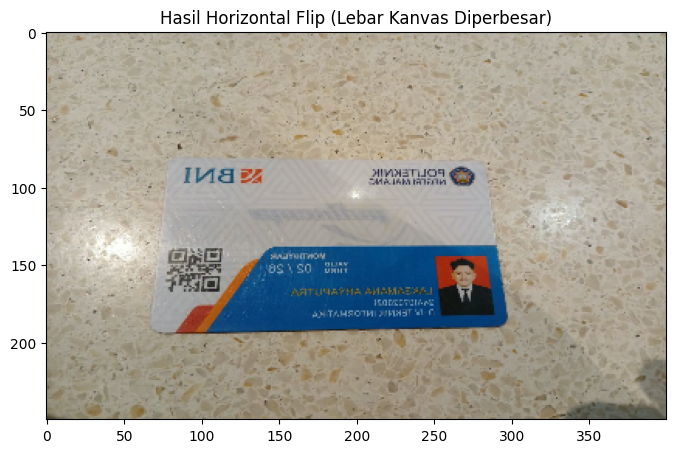

In [6]:
# 1. Resizing ukuran citra ke resolusi tertentu (lebar 400, tinggi 250)
img_small = cv2.resize(img_rgb, (400, 250))

# 2. Flipping horizontal (kode 1)
# Keterangan flipCode: 1 = Horizontal, 0 = Vertikal, -1 = Keduanya
img_flipped = cv2.flip(img_small, 1)

# Tampilkan dengan ukuran kanvas visual Matplotlib yang diperbesar
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(img_flipped)
ax.set_title("Hasil Horizontal Flip (Lebar Kanvas Diperbesar)")
plt.show()

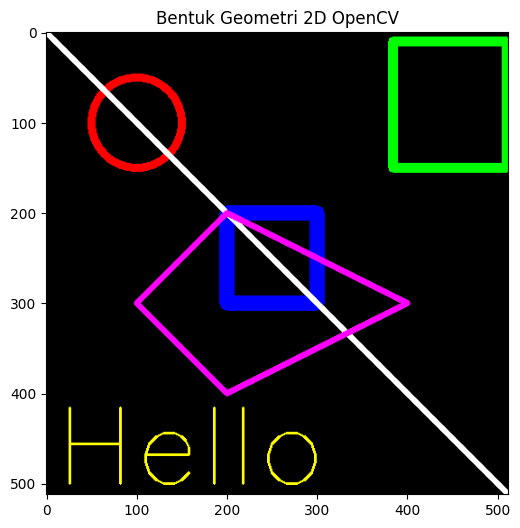

In [7]:
import numpy as np

# Buat kanvas hitam berukuran 512x512 piksel 3-channel
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)

# 1. Persegi panjang hijau (pt1=kiri-atas, pt2=kanan-bawah)
cv2.rectangle(black_img, pt1=(384, 10), pt2=(510, 150), color=(0, 255, 0), thickness=10)

# 2. Persegi biru di tengah
cv2.rectangle(black_img, pt1=(200, 200), pt2=(300, 300), color=(0, 0, 255), thickness=15)

# 3. Lingkaran merah
cv2.circle(black_img, center=(100, 100), radius=50, color=(255, 0, 0), thickness=8)

# 4. Garis diagonal putih dari pojok kiri-atas ke kanan-bawah
cv2.line(black_img, pt1=(0, 0), pt2=(512, 512), color=(255, 255, 255), thickness=5)

# 5. Menambahkan teks
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text='Hello', org=(10, 500), fontFace=font,
            fontScale=4, color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)

# 6. Poligon menggunakan vertices dengan np.int32
vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)
pts = vertices.reshape((-1, 1, 2))
cv2.polylines(black_img, [pts], isClosed=True, color=(255, 0, 255), thickness=5)

plt.figure(figsize=(6, 6))
plt.imshow(black_img)
plt.title("Bentuk Geometri 2D OpenCV")
plt.show()

Resolusi Asli Citra (Tinggi, Lebar, Channel): (960, 1280, 3)


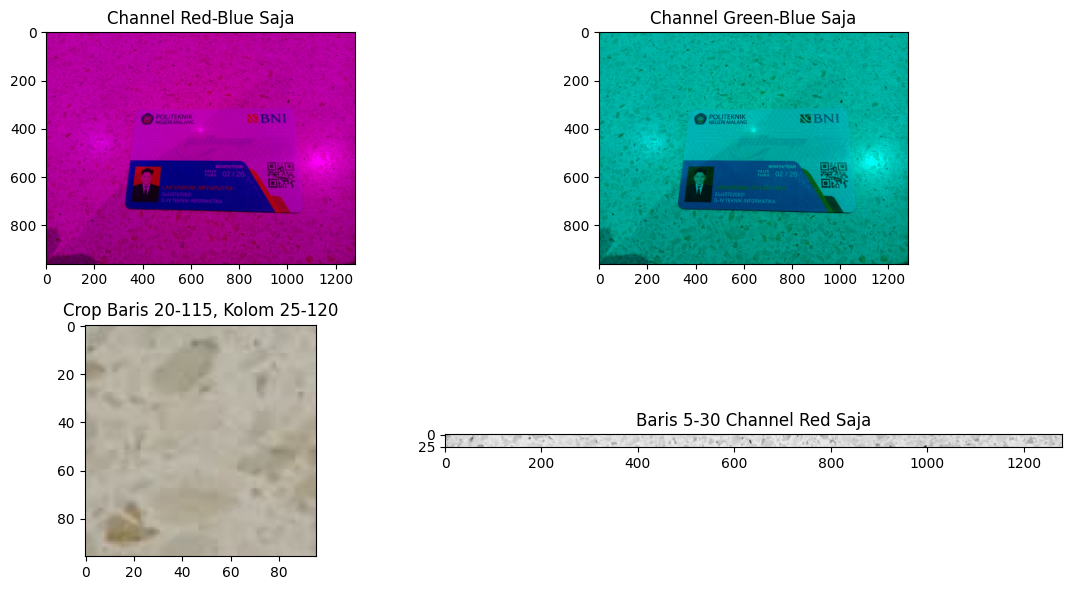

In [8]:
# TUGAS 1: Analisis figsize
print("Resolusi Asli Citra (Tinggi, Lebar, Channel):", img_rgb.shape)

# TUGAS 2: Channel Red-Blue & Green-Blue saja
# Urutan channel RGB: 0 = Red, 1 = Green, 2 = Blue

# Red-Blue saja
img_RB = img_rgb.copy()
img_RB[:, :, 1] = 0

# Green-Blue saja
img_GB = img_rgb.copy()
img_GB[:, :, 0] = 0

# TUGAS 3: Slicing Baris 20-115 dan Kolom 25-120
crop_tugas3 = img_rgb[20:116, 25:121]

# TUGAS 4: Slicing Baris 5-30, Semua Kolom, Channel Red saja
crop_tugas4_red = img_rgb[5:31, :, 0]

# Visualisasi
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.imshow(img_RB); plt.title("Channel Red-Blue Saja")
plt.subplot(2, 2, 2); plt.imshow(img_GB); plt.title("Channel Green-Blue Saja")
plt.subplot(2, 2, 3); plt.imshow(crop_tugas3); plt.title("Crop Baris 20-115, Kolom 25-120")
plt.subplot(2, 2, 4); plt.imshow(crop_tugas4_red, cmap='gray'); plt.title("Baris 5-30 Channel Red Saja")
plt.tight_layout()
plt.show()


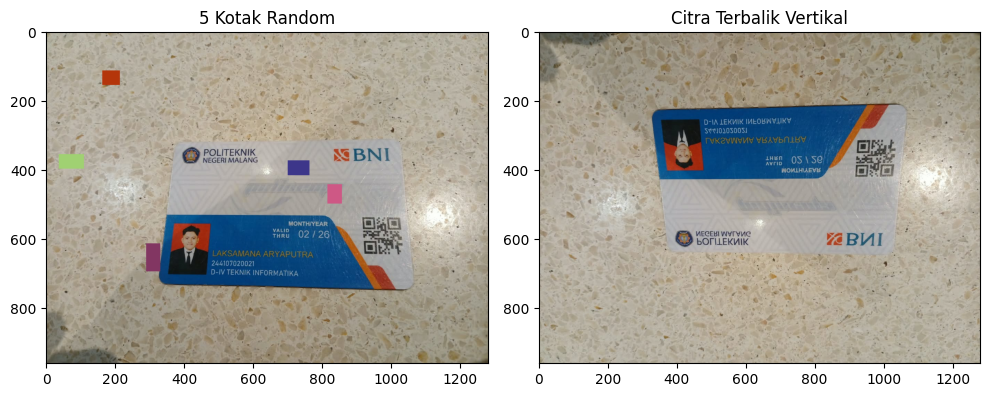

In [9]:

import random

# TUGAS 5: 5 Kotak Berbagai Ukuran & Warna Acak
img_random_boxes = img_rgb.copy()
h_img, w_img = img_random_boxes.shape[:2]

for i in range(5):
    x1 = random.randint(0, w_img - 80)
    y1 = random.randint(0, h_img - 80)
    x2 = x1 + random.randint(30, 80)
    y2 = y1 + random.randint(30, 80)

    random_color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.rectangle(img_random_boxes, (x1, y1), (x2, y2), random_color, thickness=-1)

# TUGAS 6: Posisi Terbalik (Vertikal Flip)
img_vert_flipped = cv2.flip(img_rgb, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_random_boxes); plt.title("5 Kotak Random")
plt.subplot(1, 2, 2); plt.imshow(img_vert_flipped); plt.title("Citra Terbalik Vertikal")
plt.tight_layout()
plt.show()

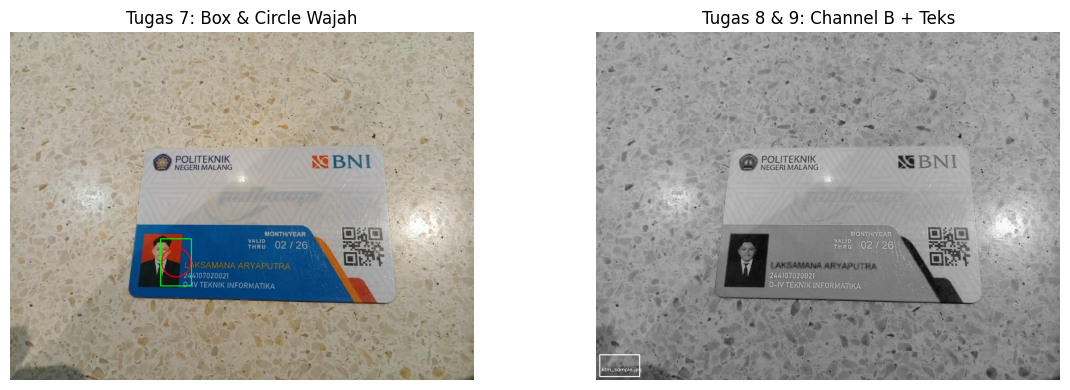

In [11]:
# TUGAS 7: Rectangle & Circle pada Bagian Wajah
# Disesuaikan dengan posisi wajah pada foto KTM

img_face = img_rgb.copy()

# Contoh: menandai area wajah pada foto KTM
cv2.rectangle(img_face, (415, 570), (500, 700), (0, 255, 0), 2)  # Box wajah
cv2.circle(img_face, (458, 635), 40, (255, 0, 0), 2)             # Lingkaran fitur


# TUGAS 8 & 9: Rectangle di sudut bawah kiri Channel Blue + Teks Nama File

# Ekstrak channel Blue (index 2)
img_b_channel = img_rgb[:, :, 2].copy()
h_b, w_b = img_b_channel.shape[:2]

# Buat rectangle di sudut kiri bawah
cv2.rectangle(
    img_b_channel,
    (10, h_b - 70),
    (120, h_b - 10),
    (255, 255, 255),
    2
)

# Beri label nama file
cv2.putText(
    img_b_channel,
    "ktm_sample.jpg",
    (15, h_b - 25),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    (255, 255, 255),
    1,
    cv2.LINE_AA
)

# Tampilkan hasil
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_face)
plt.title("Tugas 7: Box & Circle Wajah")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_b_channel, cmap="gray")
plt.title("Tugas 8 & 9: Channel B + Teks")
plt.axis("off")

plt.tight_layout()
plt.show()

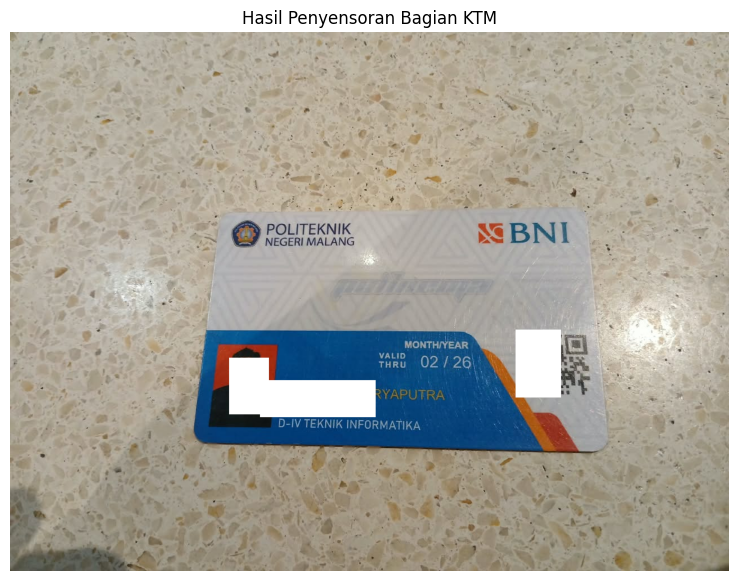

In [13]:
# Salin citra KTM untuk disensor
ktm_censored = img_rgb.copy()

# 1. Menutup Nama & NIM
cv2.rectangle(
    ktm_censored,
    (445, 620),
    (650, 685),
    (255, 255, 255),
    thickness=-1
)

# 2. Menutup Foto Mahasiswa
cv2.rectangle(
    ktm_censored,
    (390, 580),
    (460, 680),
    (255, 255, 255),
    thickness=-1
)

# 3. Menutup QR Code
cv2.rectangle(
    ktm_censored,
    (900, 530),
    (980, 650),
    (255, 255, 255),
    thickness=-1
)

# Tampilkan hasil
plt.figure(figsize=(10, 7))
plt.imshow(ktm_censored)
plt.title("Hasil Penyensoran Bagian KTM")
plt.axis("off")
plt.show()